# 00 — smoke test

Verify the pairs research loop end-to-end: load two aligned symbols, build a
log-spread + rolling z-score, render a plot via `show()`. No hypothesis yet —
this just confirms data + helpers + the headless execute/read cycle work.

Pair used purely as a sanity check: `ETHUSDT` vs `BTCUSDT` (the two most liquid
majors, obviously co-moving — good for a smoke test, not a claim of edge).

In [1]:
import sys; sys.path.insert(0, ".")   # cwd = notebooks/pairs
from _lab import *

syms = list_symbols()
print(f"{len(syms)} symbols on disk")
print("ETHUSDT coverage:", coverage("ETHUSDT"))
print("BTCUSDT coverage:", coverage("BTCUSDT"))

173 symbols on disk
ETHUSDT coverage: ('2024-01', '2026-04', 28)
BTCUSDT coverage: ('2024-01', '2026-04', 28)


In [2]:
# Aligned pair on a common 1h index (inner-join on timestamps present in both).
px = load_pair("ETHUSDT", "BTCUSDT", "2024-01-01", "2024-07-01", tf="1h")
print(f"rows={len(px)}  from {px.index[0]}  to {px.index[-1]}")
px.head()

rows=4368  from 2024-01-01 00:00:00+00:00  to 2024-06-30 23:00:00+00:00


,a,b
timestamp,,
2024-01-01 00:00:00+00:00,2297.63,42517.4
2024-01-01 01:00:00+00:00,2306.17,42661.3
2024-01-01 02:00:00+00:00,2295.26,42631.8
2024-01-01 03:00:00+00:00,2275.83,42384.1
2024-01-01 04:00:00+00:00,2281.38,42446.3


In [3]:
# Full-sample beta + spread + z-score (visualization only — uses whole window).
s = log_spread(px)
z = zscore(s, window=24 * 7)          # rolling 1-week causal z
hl = half_life(s)
print(f"beta(a~b)   = {s.attrs['beta']:.4f}")
print(f"half-life   = {hl:.1f} bars (1h) = {hl/24:.1f} days" if hl == hl else "half-life   = n/a (not mean-reverting)")
print(f"spread std  = {s.std():.4f}")

beta(a~b)   = 0.8712
half-life   = 324.4 bars (1h) = 13.5 days
spread std  = 0.0596


[saved] notebooks\pairs\_out\00_smoke_eth_btc.png


WindowsPath('C:/projects/researchlab/notebooks/pairs/_out/00_smoke_eth_btc.png')

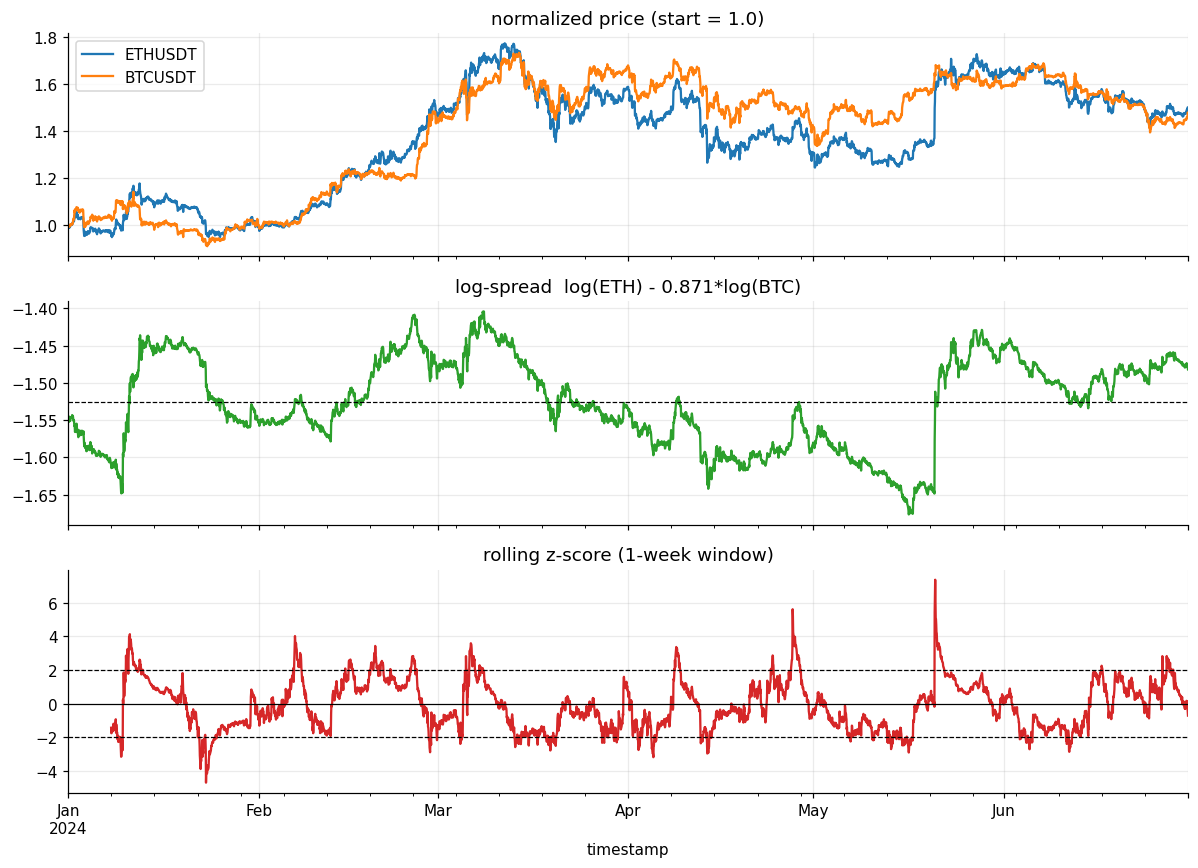

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

# normalized prices (each leg / its first value) so both fit one axis
(px["a"] / px["a"].iloc[0]).plot(ax=ax[0], label="ETHUSDT")
(px["b"] / px["b"].iloc[0]).plot(ax=ax[0], label="BTCUSDT")
ax[0].set_title("normalized price (start = 1.0)"); ax[0].legend()

s.plot(ax=ax[1], color="C2")
ax[1].axhline(s.mean(), color="k", lw=0.8, ls="--")
ax[1].set_title(f"log-spread  log(ETH) - {s.attrs['beta']:.3f}*log(BTC)")

z.plot(ax=ax[2], color="C3")
for lvl in (-2, 0, 2):
    ax[2].axhline(lvl, color="k", lw=0.8, ls="--" if lvl else "-")
ax[2].set_title("rolling z-score (1-week window)")

show("00_smoke_eth_btc")

If the three panels rendered and `_out/00_smoke_eth_btc.png` was saved, the loop
works. Next: the user proposes the first real hypothesis to test.